# Configuración de datasets


In [4]:
from google.colab import files
uploaded = files.upload()

Saving clientes.csv to clientes.csv
Saving productos.csv to productos.csv
Saving promociones.csv to promociones.csv
Saving ventas.csv to ventas.csv


# Instalando dependencias de groq (IA) pandas y matplotlib

In [6]:
!pip install pandas matplotlib groq

# Cargando Datasets

In [7]:
import pandas as pd

ventas = pd.read_csv("ventas.csv")
clientes = pd.read_csv("clientes.csv")
productos = pd.read_csv("productos.csv")
promociones = pd.read_csv("promociones.csv")

# Verficación del dataset

In [12]:
ventas.head()


,id_venta,fecha,monto,id_cliente,id_producto,id_promocion
0,1,2024-11-21,102,4,1,NaN
1,2,2024-10-17,61,5,2,2.0
2,3,2024-09-24,83,3,5,NaN
3,4,2024-10-04,105,5,5,NaN
4,5,2024-10-31,168,5,3,NaN


# Exploración inicial

In [9]:
ventas.info()
clientes.info()
productos.info()
promociones.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id_venta      100 non-null    int64  
 1   fecha         100 non-null    object 
 2   monto         100 non-null    int64  
 3   id_cliente    100 non-null    int64  
 4   id_producto   100 non-null    int64  
 5   id_promocion  48 non-null     float64
dtypes: float64(1), int64(4), object(1)
memory usage: 4.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_cliente  5 non-null      int64 
 1   nombre      5 non-null      object
 2   localidad   5 non-null      object
 3   edad        5 non-null      int64 
dtypes: int64(2), object(2)
memory usage: 292.0+ bytes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 column

### Encontramos un insight:
### 1   fecha         100 non-null    object
### Coregiremos el tipo de texto de fecha de la siguiente manera:

In [13]:
ventas["fecha"] = pd.to_datetime(ventas["fecha"])

### Corroboramos el cambio

In [14]:
ventas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id_venta      100 non-null    int64         
 1   fecha         100 non-null    datetime64[ns]
 2   monto         100 non-null    int64         
 3   id_cliente    100 non-null    int64         
 4   id_producto   100 non-null    int64         
 5   id_promocion  48 non-null     float64       
dtypes: datetime64[ns](1), float64(1), int64(4)
memory usage: 4.8 KB


# Unir tablas

### Ventas + Clientes

In [18]:
df = ventas.merge(clientes, on="id_cliente")
df.head()


,id_venta,fecha,monto,id_cliente,id_producto,id_promocion,nombre,localidad,edad
0,1,2024-11-21,102,4,1,NaN,María Fernández,Mendoza,45
1,2,2024-10-17,61,5,2,2.0,Laura Martínez,BuenosAires,17
2,3,2024-09-24,83,3,5,NaN,Carlos López,Rosario,19
3,4,2024-10-04,105,5,5,NaN,Laura Martínez,BuenosAires,17
4,5,2024-10-31,168,5,3,NaN,Laura Martínez,BuenosAires,17


### Agregar productos

In [19]:
df = df.merge(productos, on="id_producto")
df.head()

,id_venta,fecha,monto,id_cliente,id_producto,id_promocion,nombre,localidad,edad,nombre_producto,categoria,precio_base
0,1,2024-11-21,102,4,1,NaN,María Fernández,Mendoza,45,Globo,Fiesta,100
1,2,2024-10-17,61,5,2,2.0,Laura Martínez,BuenosAires,17,Cinta adhesiva,Oficina,50
2,3,2024-09-24,83,3,5,NaN,Carlos López,Rosario,19,Papel crepe,Fiesta,80
3,4,2024-10-04,105,5,5,NaN,Laura Martínez,BuenosAires,17,Papel crepe,Fiesta,80
4,5,2024-10-31,168,5,3,NaN,Laura Martínez,BuenosAires,17,Confites,Fiesta,150


### Agregar promociones

In [20]:
df = df.merge(promociones, on="id_promocion", how="left")
df.head()

,id_venta,fecha,monto,id_cliente,id_producto,id_promocion,nombre,localidad,edad,nombre_producto,categoria,precio_base,descripcion,descuento_porcentaje,fecha_inicio,fecha_fin
0,1,2024-11-21,102,4,1,NaN,María Fernández,Mendoza,45,Globo,Fiesta,100,NaN,NaN,NaN,NaN
1,2,2024-10-17,61,5,2,2.0,Laura Martínez,BuenosAires,17,Cinta adhesiva,Oficina,50,Descuento 15%,15.0,2024-09-01,2024-09-30
2,3,2024-09-24,83,3,5,NaN,Carlos López,Rosario,19,Papel crepe,Fiesta,80,NaN,NaN,NaN,NaN
3,4,2024-10-04,105,5,5,NaN,Laura Martínez,BuenosAires,17,Papel crepe,Fiesta,80,NaN,NaN,NaN,NaN
4,5,2024-10-31,168,5,3,NaN,Laura Martínez,BuenosAires,17,Confites,Fiesta,150,NaN,NaN,NaN,NaN


## Ventas por productos + Visualización

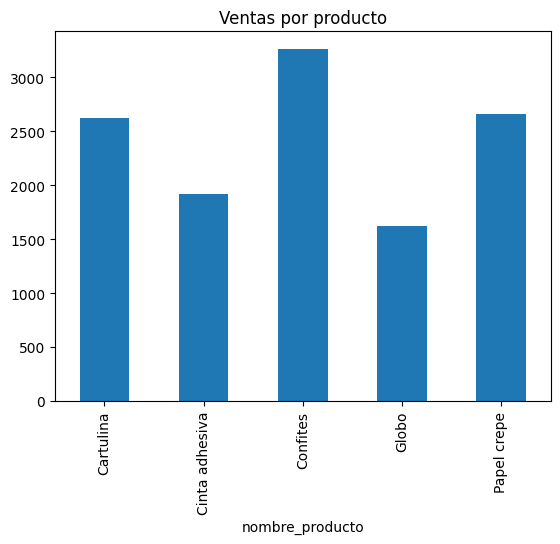

,monto
nombre_producto,
Cartulina,2621
Cinta adhesiva,1924
Confites,3263
Globo,1624
Papel crepe,2665


In [33]:
df.groupby("nombre_producto")["monto"].sum() .plot(kind="bar")
plt.title("Ventas por producto")
plt.show()

df.groupby("nombre_producto")["monto"].sum()

## Venta por categoria

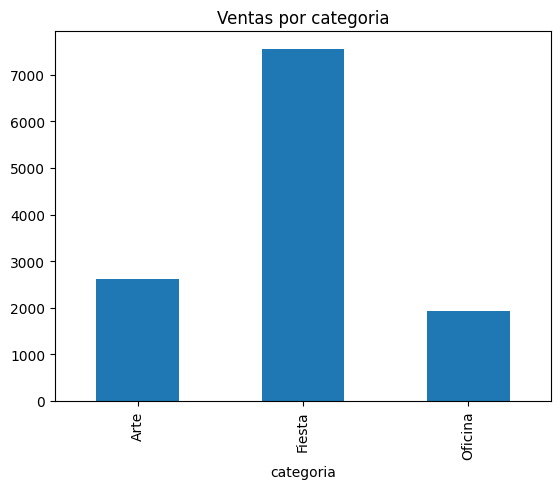

,monto
categoria,
Arte,2621
Fiesta,7552
Oficina,1924


In [40]:


df.groupby("categoria")["monto"].sum().plot(kind="bar")

plt.title("Ventas por categoria")
plt.show()

df.groupby("categoria")["monto"].sum()

## Venta por ciudad

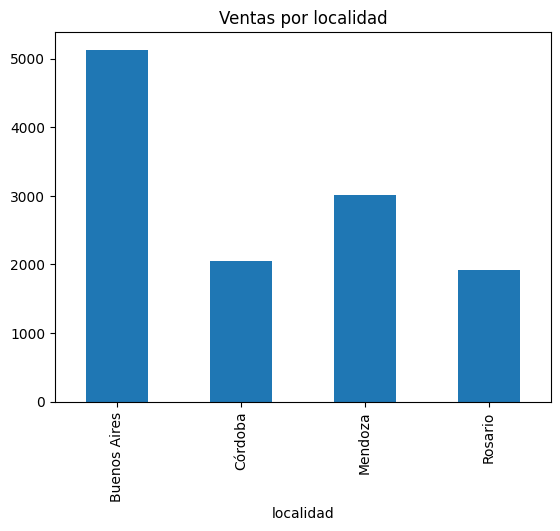

,monto
localidad,
Buenos Aires,5131
Córdoba,2043
Mendoza,3012
Rosario,1911


In [38]:
df.groupby("localidad")["monto"].sum() .plot(kind="bar")
plt.title("Ventas por localidad")
plt.show()

df['localidad'] = df['localidad'].replace('BuenosAires', 'Buenos Aires')
df.groupby("localidad")["monto"].sum()

## Ventas por edad

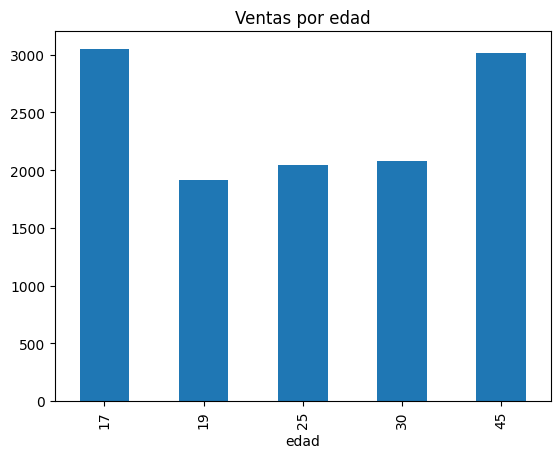

,monto
edad,
17,3049
19,1911
25,2043
30,2082
45,3012


In [37]:
df.groupby("edad")["monto"].sum().plot(kind="bar")
plt.title("Ventas por edad")
plt.show()
df.groupby("edad")["monto"].sum()



# Resumen para la IA

In [46]:
summary = {
    "ventas_totales": df["monto"].sum(),
    "ventas_promedio": df["monto"].mean,
    "ventas_por_categoria": df.groupby("categoria")["monto"].sum().to_dict(),
    "ventas_por_localidad": df.groupby("localidad")["monto"].sum().to_dict()
}

summary

{'ventas_totales': np.int64(12097),
 'ventas_promedio': <bound method Series.mean of 0     102
 1      61
 2      83
 3     105
 4     168
      ... 
 95    163
 96    125
 97    151
 98    104
 99    116
 Name: monto, Length: 100, dtype: int64>,
 'ventas_por_categoria': {'Arte': 2621, 'Fiesta': 7552, 'Oficina': 1924},
 'ventas_por_localidad': {'Buenos Aires': 5131,
  'Córdoba': 2043,
  'Mendoza': 3012,
  'Rosario': 1911}}

# Analizando con Groq (IA)

In [54]:
from google.colab import userdata
import os
api_key = userdata.get("GROQ_API_KEY") ## Solicitar Acceso

In [56]:
from groq import Groq
import json
import numpy as np # Import numpy to handle its types if needed, though direct conversion is better

client = Groq(api_key=api_key)
# Create a serializable version of the summary dictionary
# Convert numpy.int64 to int and call the .mean() method to get the value
serializable_summary = {
    "ventas_totales": int(summary["ventas_totales"]),
    "ventas_promedio": float(summary["ventas_promedio"]()), # Call the mean method
    "ventas_por_categoria": summary["ventas_por_categoria"],
    "ventas_por_localidad": summary["ventas_por_localidad"]
}

prompt = f"""
Analiza estos datos de ventas y genera insights de negocio:

{json.dumps(serializable_summary, indent=2)}

Explica:
- patrones de ventas
- productos fuertes
- recomendaciones comerciales
"""

response = client.chat.completions.create(
    model="llama-3.1-8b-instant", ##Modelo Actualizado
    messages=[{"role": "user", "content": prompt}]
)

print(response.choices[0].message.content)

**Análisis de datos de ventas**

A continuación, se presentan algunos de los patrones y tendencias identificados en los datos de ventas:

### Patrones de ventas

1. **Mayor cantidad de ventas en la categoría de "Fiesta"**: La categoría de "Fiesta" representa el 62,5% de las ventas totales, lo que sugiere que hay una gran demanda de productos relacionados con eventos y celebraciones.
2. **Menor cantidad de ventas en la categoría de "Oficina"**: La categoría de "Oficina" representa solo el 15,9% de las ventas totales, lo que sugiere que la demanda de productos para oficinas es menor en comparación con las otras categorías.
3. **Mayor cantidad de ventas en la localidad de Buenos Aires**: La localidad de Buenos Aires representa el 42,3% de las ventas totales, lo que sugiere que hay una gran demanda de productos en esta región.

### Productos fuertes

1. **Categoría de "Fiesta" con el mayor valor de ventas**: La categoría de "Fiesta" tiene el mayor valor de ventas, lo que sugiere que los pr